# Arbol de Decision (Decision Tree Classifier) en Python

# 1. Cargar Librerías

In [ ]:
import pandas as pd  #contiene funciones que nos ayudan en el análisis exploratorio
import numpy as np   #util para realizar calculos avanzados
import seaborn as sns                       #visualisation  Seaborn es una biblioteca de visualización de datos basada en matplotlib
import matplotlib.pyplot as plt             #visualisation para crear graficos de muy buena calidad

# se utiliza para visualizar las graficas en este notebook
%matplotlib inline

# 2. Cargar Data Set


In [ ]:
df = pd.read_csv("uso_internet_espana.csv")

In [ ]:
#obtenemos una muestra de 10 personas
df.sample(10)

,Unnamed: 0,uso_internet,sexo,edad,estudios
403,406,1,Mujer,28,Superiores
85,87,1,Mujer,23,Primaria
917,925,1,Hombre,31,F.P.
259,262,0,Mujer,58,Superiores
1542,1557,1,Mujer,43,Primaria
940,949,0,Mujer,85,Primaria
2056,2076,0,Mujer,69,Primaria
1018,1027,0,Mujer,46,Primaria
2294,2315,0,Mujer,39,F.P.
932,940,1,Hombre,44,F.P.


# 3. Objetivo del Análisis

Predecir el uso de Internet basandose en las variables Sexo, Edad y Estudios.

# 4. Transformar variables categóricas a numéricas

In [ ]:
#https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
pd.get_dummies(data=df,drop_first=True,dtype=int)

,Unnamed: 0,uso_internet,edad,sexo_Mujer,estudios_Medios universitarios,estudios_Primaria,estudios_Secundaria,estudios_Sin estudios,estudios_Superiores
0,1,0,66,1,0,1,0,0,0
1,2,1,72,0,0,1,0,0,0
2,3,1,48,0,1,0,0,0,0
3,4,0,59,0,0,0,0,0,1
4,5,1,44,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
2450,2471,1,43,0,0,1,0,0,0
2451,2472,1,18,1,0,0,1,0,0
2452,2473,0,54,1,0,1,0,0,0
2453,2474,1,31,0,0,0,1,0,0


In [ ]:
df=pd.get_dummies(data=df,drop_first=True,dtype=int)

# 5. Selección de variables

In [ ]:
#seleccionar todas las variables menos la variable uso_internet
variables_explicativas = df.drop(columns="uso_internet")
variable_objetivo = df.uso_internet

# 6. Entrenar Modelo DecisionTreeClassifier()

usar la función fit que entrena el modelo

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X=variables_explicativas, y=variable_objetivo)
DecisionTreeClassifier()

DecisionTreeClassifier()

el modelo ya se ha calculado

# 7. Visualizar modelo

In [ ]:
from sklearn.tree import plot_tree

[Text(0.5640514857802625, 0.9827586206896551, 'edad <= 48.5\ngini = 0.497\nsamples = 2455\nvalue = [1140, 1315]'),
 Text(0.23875410184735052, 0.9482758620689655, 'estudios_Primaria <= 0.5\ngini = 0.344\nsamples = 1412\nvalue = [312, 1100]'),
 Text(0.11676845324906822, 0.9137931034482759, 'estudios_Sin estudios <= 0.5\ngini = 0.176\nsamples = 849\nvalue = [83, 766]'),
 Text(0.11417568060281964, 0.8793103448275862, 'edad <= 36.5\ngini = 0.168\nsamples = 844\nvalue = [78, 766]'),
 Text(0.036217792902284884, 0.8448275862068966, 'Unnamed: 0 <= 218.5\ngini = 0.104\nsamples = 526\nvalue = [29, 497]'),
 Text(0.012963863231242911, 0.8103448275862069, 'Unnamed: 0 <= 206.5\ngini = 0.35\nsamples = 31\nvalue = [7, 24]'),
 Text(0.010371090584994328, 0.7758620689655172, 'Unnamed: 0 <= 151.5\ngini = 0.245\nsamples = 28\nvalue = [4, 24]'),
 Text(0.005185545292497164, 0.7413793103448276, 'edad <= 31.0\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.002592772646248582, 0.7068965517241379, 'gini =

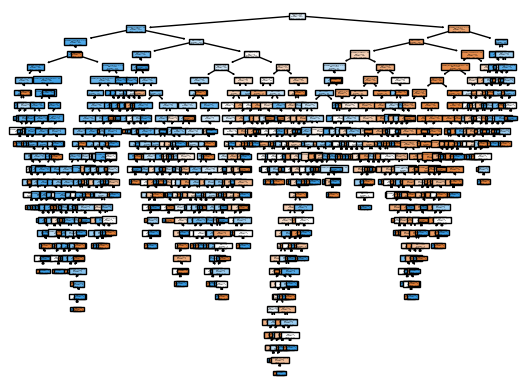

In [ ]:
#filled=True para colorear el arbol
plot_tree(decision_tree=model,feature_names=variables_explicativas.columns, filled=True)

como resultado es un árbol muy grande. Para que no resulte de esta forma lo acotaremos con 3 niveles de profundidad.

In [ ]:
from sklearn.tree import plot_tree


In [ ]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X=variables_explicativas, y=variable_objetivo)
DecisionTreeClassifier(max_depth=3)

DecisionTreeClassifier(max_depth=3)

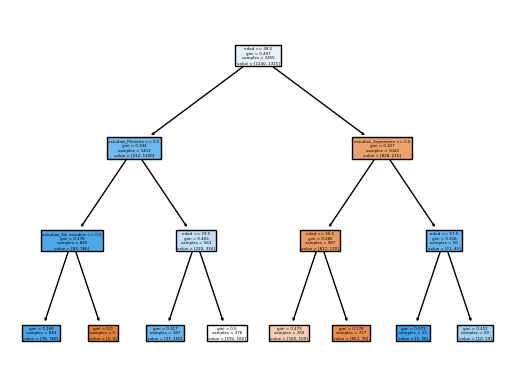

In [ ]:
plot_tree(decision_tree=model,feature_names=variables_explicativas.columns, filled=True);

In [ ]:
#con el propósito de agrandar el tamaño del árbol usaremos otra librería
import matplotlib.pyplot as plt

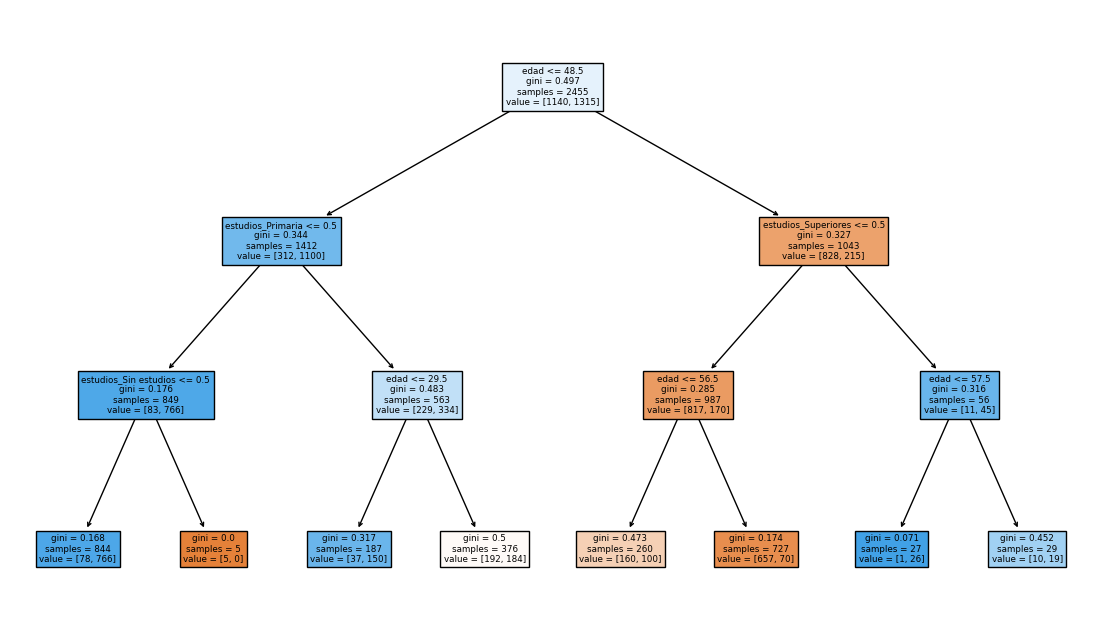

In [ ]:
plt.figure(figsize=(14,8))
plot_tree(decision_tree=model,feature_names=variables_explicativas.columns, filled=True);

# 8. Calcular Predicción

In [ ]:
#elegir una persona al azar
a=variables_explicativas.sample()

In [ ]:
a

,Unnamed: 0,edad,sexo_Mujer,estudios_Medios universitarios,estudios_Primaria,estudios_Secundaria,estudios_Sin estudios,estudios_Superiores
2249,2270,39,1,0,0,0,0,1


Persona 2249 de 39 años, mujer y tiene estudios superiores. La probabilidad que haya usado internet ¿?

In [ ]:
766/844

0.9075829383886256

In [ ]:
#predicción del modelo
model.predict_proba(a)

array([[0.09241706, 0.90758294]])

In [ ]:
#predicción de todas las variables
model.predict(variables_explicativas)

array([0, 0, 1, ..., 0, 1, 0])

In [ ]:
#total de registros
model.predict(variables_explicativas).shape

(2455,)

In [ ]:
#guardar en y_predict todas las predicciones del dataframe de acuerdo al modelo
y_predict=model.predict(variables_explicativas)

de acuerdo al árbol se interpreta que el modelo considera a la edad como la variable mas influyente para determinar si una persona usa internet o no


# 9. Interpretar Modelo

realizar histograma

In [ ]:
import seaborn as sns

<Axes: xlabel='edad', ylabel='Count'>

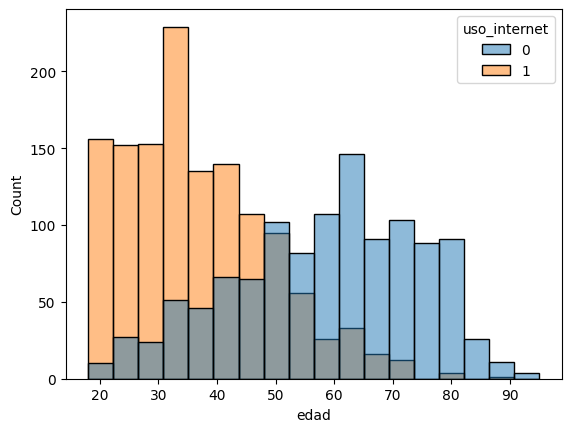

In [ ]:
sns.histplot(x=df.edad, hue=df.uso_internet)

Si revisamos el histograma, podemos entender que el modelo ha determinado que la variable edad es la variable más importante dada la frecuencia marcada de edades mas jovenes en el uso de internet no así para las edades mayores.

# 7. Como de Bueno es el Modelo

In [ ]:
#ingrecemos al dataframe las predicciones del modelo
df['pred']= y_predict

In [ ]:
#obtengamos una muestra de 10 personas
df.sample(10)

,Unnamed: 0,uso_internet,edad,sexo_Mujer,estudios_Medios universitarios,estudios_Primaria,estudios_Secundaria,estudios_Sin estudios,estudios_Superiores,pred
864,872,1,42,1,0,0,0,0,0,1
2454,2475,0,52,0,0,1,0,0,0,0
2066,2086,0,60,1,0,1,0,0,0,0
1957,1975,0,70,1,0,1,0,0,0,0
795,803,0,52,1,0,1,0,0,0,0
1290,1303,1,39,0,0,0,1,0,0,1
300,303,1,51,1,0,0,1,0,0,0
1215,1225,1,48,1,0,0,1,0,0,1
850,858,0,59,0,0,1,0,0,0,0
858,866,1,33,0,0,0,0,0,0,1


In [ ]:
#revisemos solo las columnas uso_internet y pred
df.sample(10)[["uso_internet","pred"]]


,uso_internet,pred
1126,0,0
272,1,1
35,0,1
1269,1,0
572,0,0
823,1,1
1393,1,1
155,0,0
2089,1,0
2365,0,0


Como se puede visualizar para las personas, 35-1269-2089 el modelo predijo todo lo contrario....

¿que nivel de exactitud posee el modelo?

In [ ]:
#¡como comparamos el acierto del modelo
df['uso_internet']==df['pred']

,0
0,True
1,False
2,True
3,False
4,True
...,...
2450,False
2451,True
2452,True
2453,True


In [ ]:
# si realizamos la suma de 1 y zeros se tienen
#obtener el numero de aciertos
(df['uso_internet']==df['pred']).sum()

1975

In [ ]:
#porcentajes de aciertos
#1975/2455
(df['uso_internet']==df['pred']).sum()/2455

0.8044806517311609

Finalmente podemos decir que nuestro modelo es bueno un 80%.